In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az
import pytensor.tensor as pt

from pytrends.request import TrendReq

In [ ]:
az.style.use("arviz-darkgrid")

In [ ]:
# data

pytrends = TrendReq(hl="en-US", tz=360)

kw_list = ["Temu"]
timeframe = "2022-10-01 2023-06-01"

pytrends.build_payload(
    kw_list=kw_list,
    cat=0,
    timeframe=timeframe,
    geo="US",
    gprop=""
)

data = pytrends.interest_over_time().reset_index()
data = data.drop(columns=["isPartial"])
data.to_csv("temu_google_trends.csv", index=False)

df = data.copy()
df["date"] = pd.to_datetime(df["date"])


In [ ]:
ad_date = pd.to_datetime("2023-02-12")

df["date"] = pd.to_datetime(df["date"])
df["date_num"] = (df["date"] - df["date"].min()).dt.days
df["post_t"] = (df["date"] >= ad_date).astype(int)

y_obs = df["Temu"].values
t_data = df["date_num"].values
post_t = df["post_t"].values

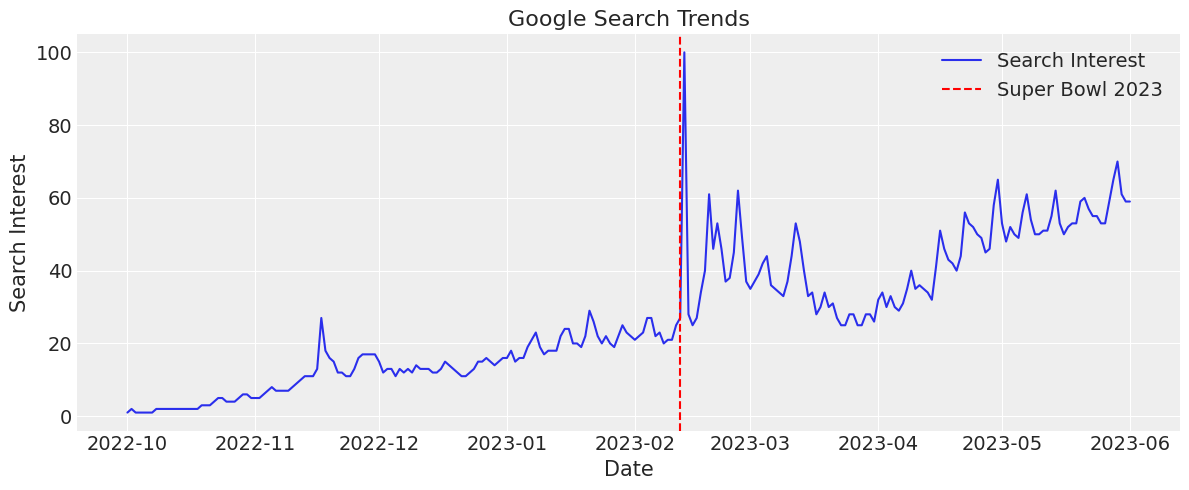

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['Temu'], label="Search Interest")
plt.axvline(pd.to_datetime("2023-02-12"), color='red', linestyle='--', label='Super Bowl 2023')
# plt.axvline(pd.to_datetime("2024-02-11"), color='pink', linestyle='--', label='Super Bowl 2024')
plt.title("Google Search Trends")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

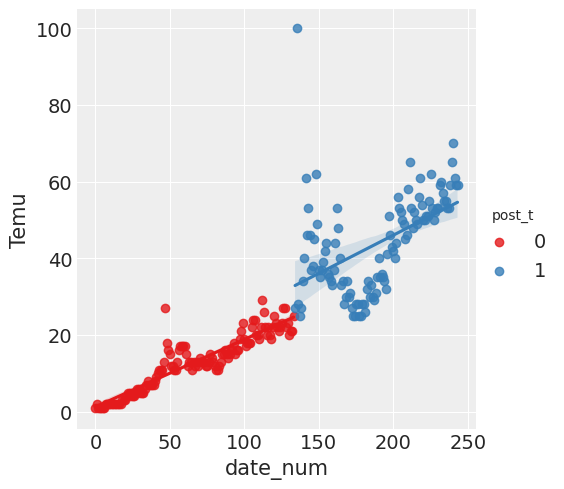

In [ ]:
sns.lmplot(x="date_num", y="Temu", hue="post_t", data=df, palette="Set1")

model

In [ ]:
with pm.Model() as model:
    alpha = pm.Normal("alpha", mu=df["Temu"].mean(), sigma=20)
    beta_time = pm.Normal("beta_time", mu=0, sigma=5)
    beta_ad = pm.Normal("beta_ad", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta_time * t_data + beta_ad * post_t

    y = pm.TruncatedNormal(
        "y",
        mu=mu,
        sigma=sigma,
        lower=0,
        upper=100,
        observed=y_obs
    )

prior

In [ ]:
with model:
    prior = pm.sample_prior_predictive()

<Axes: xlabel='y'>

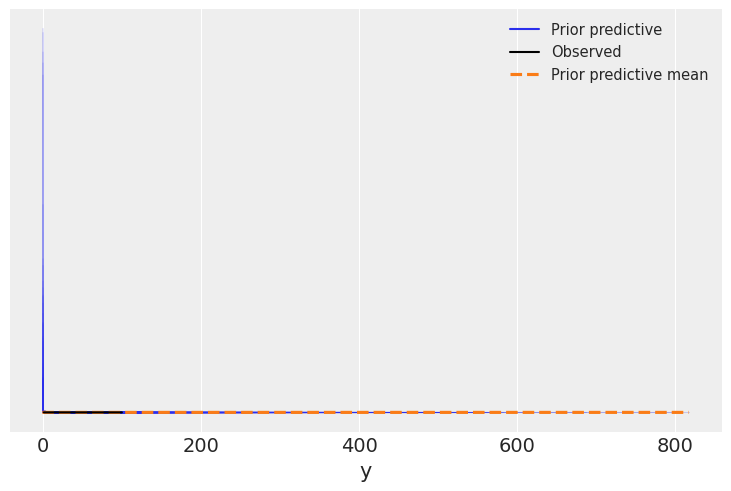

In [ ]:
# az.plot_ppc(prior, group="prior", observed=True)

<Axes: xlabel='y'>

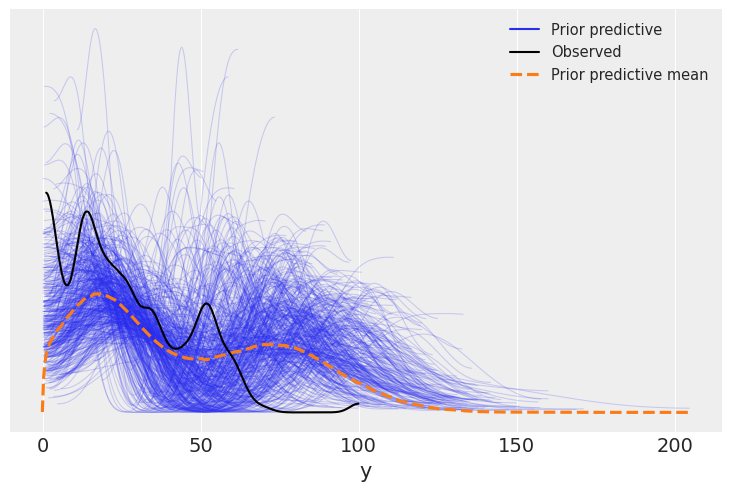

In [ ]:
az.plot_ppc(prior, group="prior", observed=True)



*  ***Prior Distributions***



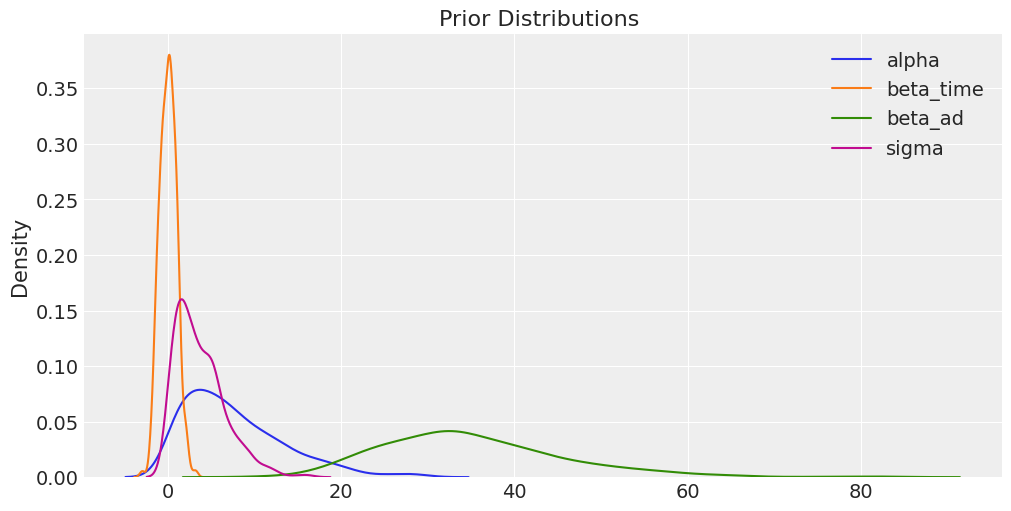

In [ ]:
beta_ad = prior.prior["beta_ad"].stack(sample=("chain", "draw")).values
beta_time = prior.prior["beta_time"].stack(sample=("chain", "draw")).values
alpha_vals = prior.prior["alpha"].stack(sample=("chain", "draw")).values
sigma_vals = prior.prior["sigma"].stack(sample=("chain", "draw")).values

plt.figure(figsize=(10, 5))
sns.kdeplot(alpha_vals, label="alpha")
sns.kdeplot(beta_time, label="beta_time")
sns.kdeplot(beta_ad, label="beta_ad")
sns.kdeplot(sigma_vals, label="sigma")
plt.title("Prior Distributions ")

plt.legend()
plt.show()

*  ***Prior Predictive Check***

In [ ]:
ys = prior.prior_predictive["y"].stack(sample=("chain", "draw")).values

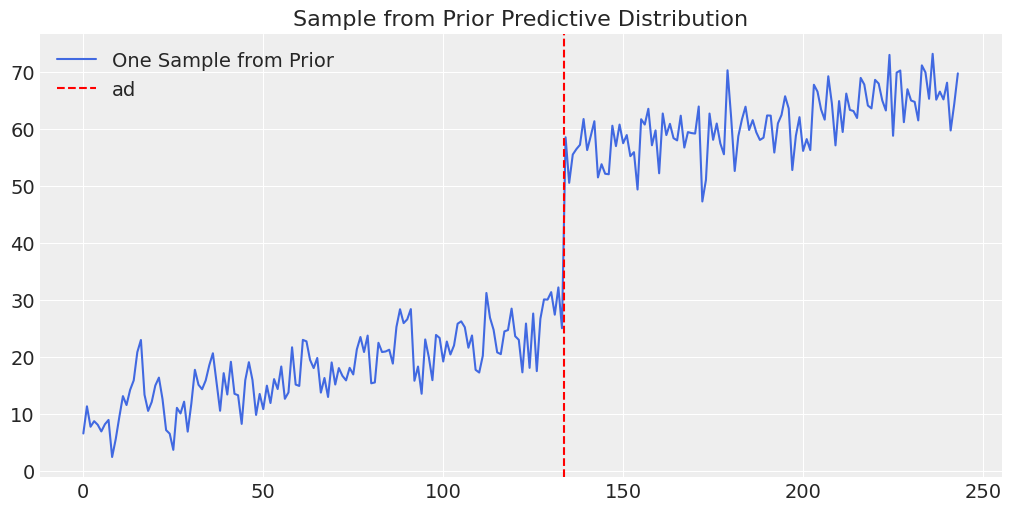

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(ys[:, 0], label="One Sample from Prior", color="royalblue")

plt.axvline(np.where(post_t==1)[0][0] - 0.5, color="red", linestyle="--", label="ad")

plt.title("Sample from Prior Predictive Distribution")

plt.legend()
plt.show()

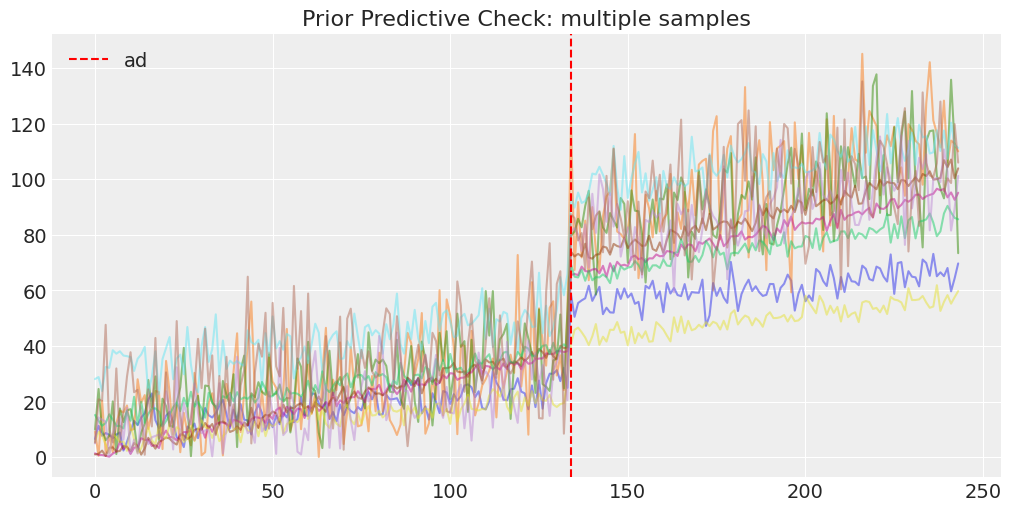

In [ ]:
ys = prior.prior_predictive["y"].stack(sample=("chain", "draw")).values

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.plot(ys[:, i], alpha=0.5)

plt.axvline(np.where(post_t == 1)[0][0], color="red", linestyle="--", label="ad")
plt.title("Prior Predictive Check: multiple samples")
plt.legend()
plt.show()

Sampling



In [ ]:
with model:
    trace = pm.sample()

Output()

In [ ]:
# with model:
#     trace = pm.sample(
#         draws=2000,
#         tune=1000,
#         target_accept=0.9,
#         random_seed=42
#     )

In [ ]:

az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.500,0.456,0.001,1.350,0.014,0.016,897.0,668.0,1.0
beta_ad,12.675,1.722,9.360,15.856,0.063,0.047,751.0,707.0,1.0
beta_time,0.165,0.009,0.149,0.184,0.000,0.000,678.0,576.0,1.0
sigma,8.296,0.415,7.532,9.074,0.015,0.013,828.0,894.0,1.0


Posterior



array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_ad'}>,
        <Axes: title={'center': 'beta_ad'}>],
       [<Axes: title={'center': 'beta_time'}>,
        <Axes: title={'center': 'beta_time'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

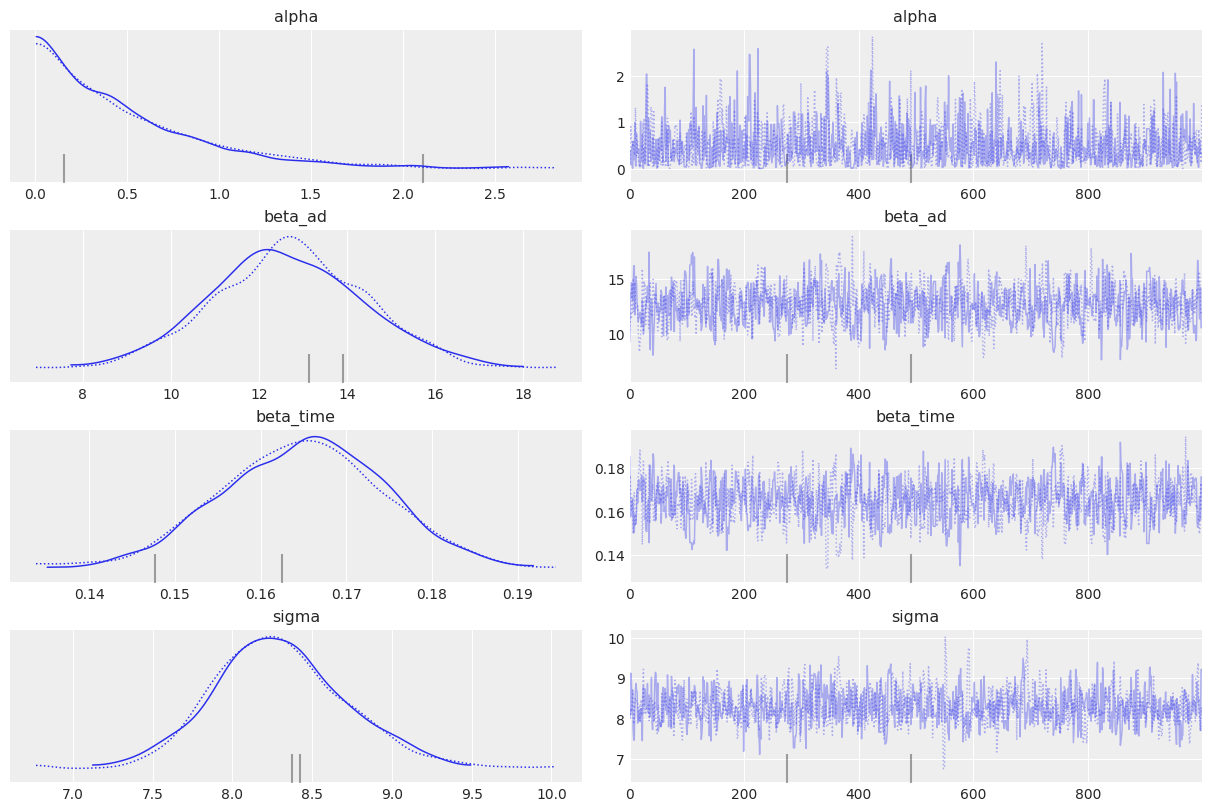

In [ ]:
az.plot_trace(trace)

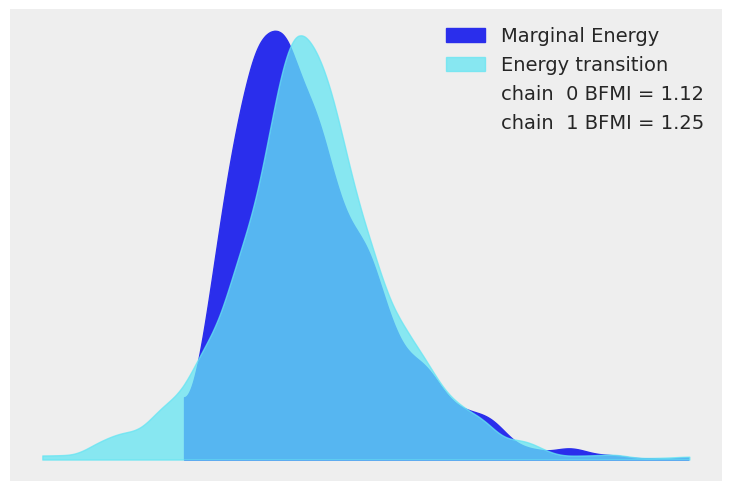

In [ ]:
az.plot_energy(trace);

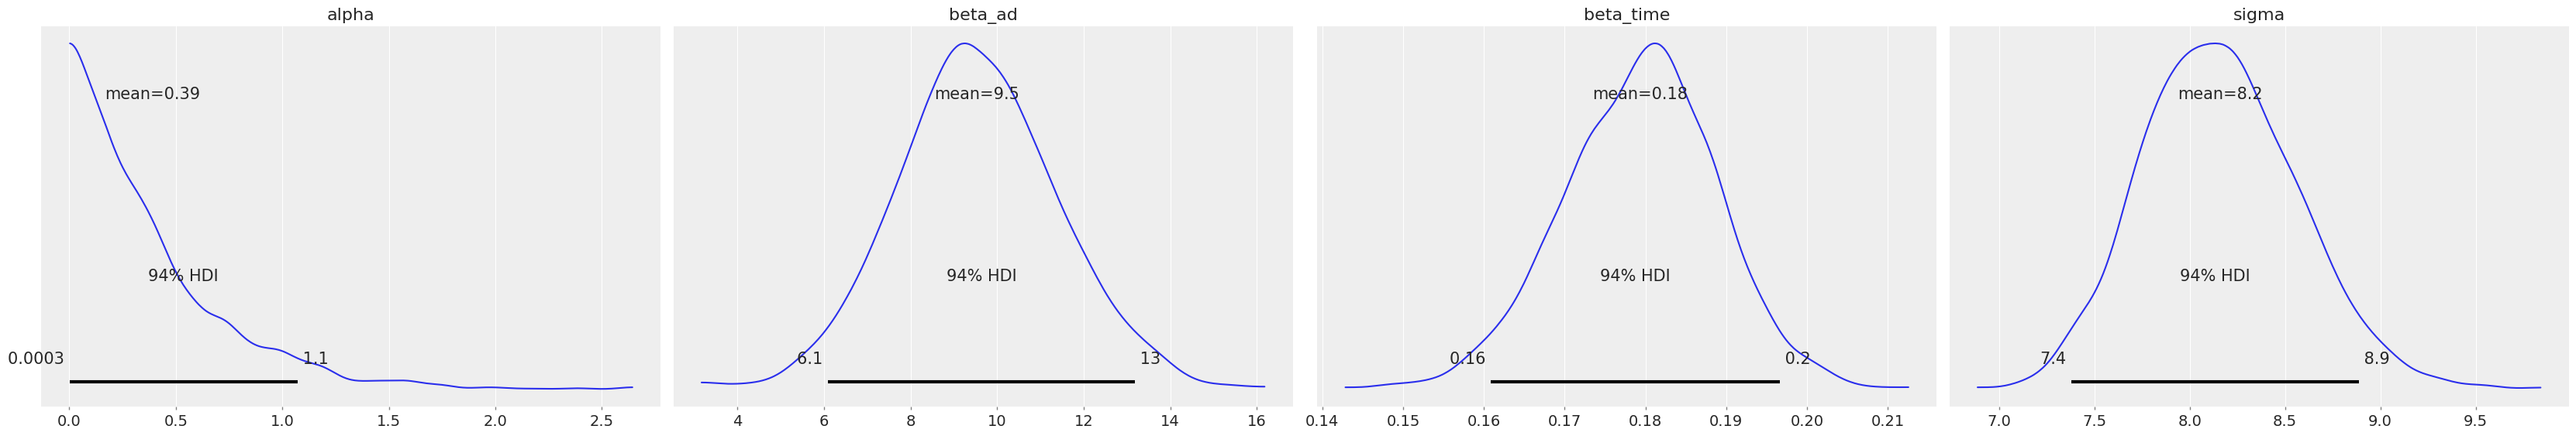

In [ ]:

az.plot_posterior(trace);

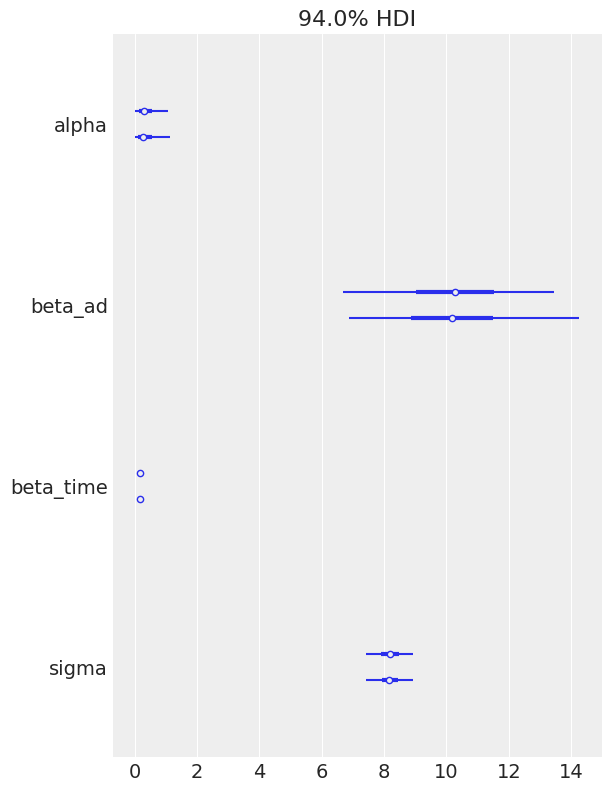

In [ ]:
az.plot_forest(trace);

In [ ]:
with model:
    posterior_pred = pm.sample_posterior_predictive(trace)

Output()

<Axes: xlabel='y'>

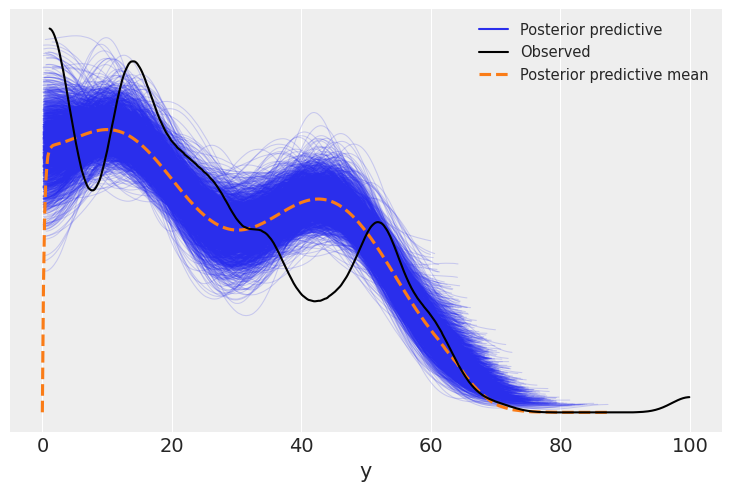

In [ ]:
az.plot_ppc(posterior_pred, group="posterior", observed=True)

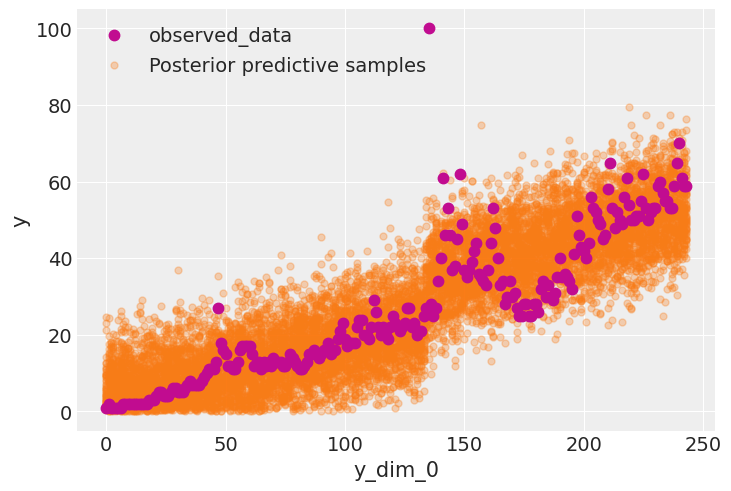

In [ ]:
az.plot_lm("y", posterior_pred);

<Axes: title={'center': 'beta_ad'}>

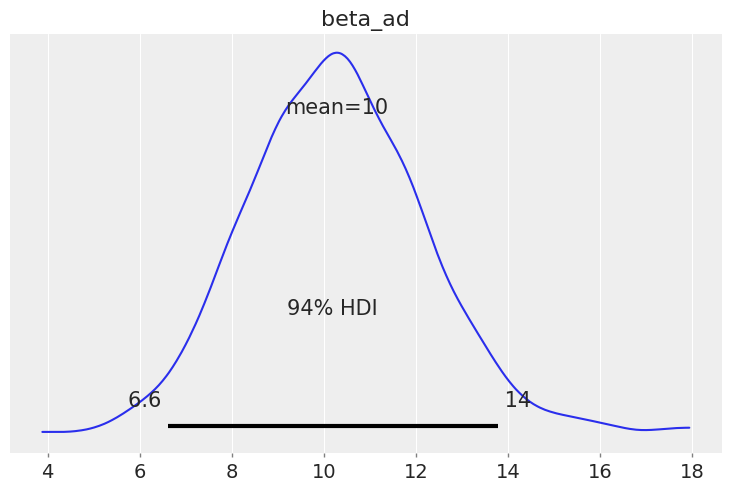

In [ ]:
az.plot_posterior(trace, var_names=["beta_ad"])

The posterior distribution of `beta_ad` is concentrated above zero, suggesting a positive increase in search interest after the Super Bowl advertisement.